<a href="https://colab.research.google.com/github/nmansour67/skills-introduction-to-github/blob/main/Creative_Research_MultiDB20260505.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creative Research & Economic Development — Multi-Database Pipeline
**Arab Academy of Science | Book Chapter**
**Author: Nabil Mansour, AUBMC**

---
## HOW TO USE THIS NOTEBOOK

| Situation | What to run |
|---|---|
| **First time ever** | Run ALL cells top to bottom |
| **Colab restarted** | Run CELL 0 only — everything reloads from Drive |
| **Databases already fetched** | Run CELL 0, skip to CELL 6 (embedding) |
| **Embedding already done** | Run CELL 0, skip to CELL 7 (clustering) |
| **Lens enrichment already done** | Run CELL 0, skip to CELL 16 |

**Databases used:** NCBI/PubMed · EuropePMC · Elsevier/Scopus · Web of Science · PubMedBERT
**Date range:** 2015 – 2026
**All files saved permanently to Google Drive.**

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 0 — MASTER SETUP & SMART RECOVERY                        ║
# ║  Run this FIRST every single session. Takes ~90 seconds.        ║
# ║  Mounts Drive, loads secrets, restores all saved data.          ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, sys, warnings
warnings.filterwarnings("ignore")

# ── 1. Mount Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/CreativeResearch"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"✅ Drive mounted — working directory: {PROJECT_DIR}")

# ── 2. Install libraries ──────────────────────────────────────────
print("Installing libraries (silent)...")
os.system("pip install sentence-transformers scikit-learn pandas numpy "
          "matplotlib seaborn requests tqdm umap-learn plotly scipy "
          "rapidfuzz -q")
print("✅ Libraries ready")

# ── 3. Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import requests, time, re
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp
from google.colab import userdata
print("✅ All imports successful")

# ── Hardcoded API key (less secure, use Colab Secrets preferably) ─────────
HARDCODED_ELSEVIER_KEY = "81e21feb0a7b5e935f16d4aad8167399"

# ── 4. Load ALL API keys from Colab Secrets (crash-safe) ─────────
def get_secret(name):
    if name == "Elsevier" and HARDCODED_ELSEVIER_KEY:
        print(f"   ✅ {name} (hardcoded)")
        return HARDCODED_ELSEVIER_KEY
    try:
        val = userdata.get(name)
        if val and str(val).strip():
            print(f"   ✅ {name}")
            return str(val).strip()
        else:
            print(f"   ⚠️  {name} — empty value")
            return None
    except Exception:
        # Secret does not exist at all — not an error, just skip
        print(f"   ➖ {name} — not configured (will use free fallback)")
        return None

print("Loading API keys from Colab Secrets:")
NCBI_KEY      = get_secret("NCBI")
EUROPEPMC_KEY = get_secret("EuropePMC")
ELSEVIER_KEY  = get_secret("Elsevier")
WOS_KEY       = get_secret("WOS_API_KEY")
HF_TOKEN      = get_secret("PubMedBert")
LENS_TOKEN    = get_secret("LENS_SCHOLARLY_TOKEN")


# ── 5. List files already on Drive ───────────────────────────────
files = os.listdir(PROJECT_DIR)
print(f"\nFiles on Drive ({len(files)} total):")
key_files = [
    "pubmed_corpus_ncbi.csv", "pubmed_corpus_europepmc.csv",
    "pubmed_corpus_elsevier.csv", # Removed "pubmed_corpus_wos.csv"
    "pubmed_corpus_merged.csv", "pubmed_corpus_enriched.csv",
    "pubmed_embeddings.npy", "citation_by_cluster.csv"
]
for f in key_files:
    if f in files:
        kb = os.path.getsize(f) / 1024
        print(f"   ✅ {f:<45} {kb:>8.0f} KB")
    else:
        print(f"   ⏳ {f:<45} (not yet generated)")

# ── 6. Smart reload — best available corpus ───────────────────────
df = None
embeddings = None
model = None
N_CLUSTERS = 30

for fname in ["pubmed_corpus_enriched.csv",
              "pubmed_corpus_merged.csv"]:
    if fname in files:
        df = pd.read_csv(fname)
        print(f"\n✅ Loaded corpus: {fname} — {len(df):,} articles")
        break

if df is None:
    print("\n⚠️  No merged corpus found → run CELLS 1–5")

if "pubmed_embeddings.npy" in files:
    embeddings = np.load("pubmed_embeddings.npy")
    print(f"✅ Loaded embeddings: {embeddings.shape}")
else:
    print("⚠️  No embeddings found → run CELL 6")

# ── 7. Re-apply clustering and labels if data exists ─────────────
CUSTOM_STOPS = [
    "ai","artificial","intelligence","artificial intelligence",
    "machine","learning","machine learning","deep","deep learning",
    "health","healthcare","health care","care","medical","clinical",
    "patient","patients","data","model","models","study","studies",
    "use","used","using","based","approach","methods","method",
    "result","results","performance","accuracy","dataset","system",
    "proposed","review","paper","algorithm","neural","network",
    "training","test","trained","prediction","predicted",
    "aim","aims","objective","background","conclusion",
    "introduction","abstract","significant","analysis",
    "developed","development","improve","improvement","novel",
    "demonstrate","demonstrated","shows","showed","high","low",
    "large","small","new","current","recent","potential",
    "based","using","used","different","showed","found",
    "compared","including","within","without","between","among",
]

if df is not None and embeddings is not None and len(df) == len(embeddings):
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    df["cluster"] = kmeans.fit_predict(embeddings)

    vec = TfidfVectorizer(
        max_features=80000, stop_words="english",
        ngram_range=(1, 3), sublinear_tf=True, min_df=3, max_df=0.6
    )
    tfidf_matrix = vec.fit_transform(df["full_text"].fillna(""))
    feature_names = vec.get_feature_names_out()
    custom_stop_set = set(CUSTOM_STOPS)
    zero_cols = [i for i, f in enumerate(feature_names) if f in custom_stop_set]
    tfidf_lil = sp.lil_matrix(tfidf_matrix)
    for col in zero_cols:
        tfidf_lil[:, col] = 0
    tfidf_matrix = tfidf_lil.tocsr()
    cluster_names = {}
    for cid in range(N_CLUSTERS):
        mask = df["cluster"] == cid
        if mask.sum() == 0:
            cluster_names[cid] = f"cluster_{cid}"
            continue
        ctfidf = tfidf_matrix[mask.to_numpy()].mean(axis=0)
        top_idx = np.asarray(ctfidf).flatten().argsort()[-5:][::-1]
        cluster_names[cid] = " | ".join([feature_names[i] for i in top_idx])
    df["cluster_name"] = df["cluster"].map(cluster_names)
    print(f"✅ Clustering applied: {N_CLUSTERS} clusters")
elif df is not None and embeddings is not None:
    print(f"⚠️  Shape mismatch: df={len(df)} rows, embeddings={embeddings.shape[0]} rows")
    print("   → Run CELL 5 (merge) then CELL 6 (re-embed)")

# ── 8. Load PubMedBERT model ─────────────────────────────────────
print("\nLoading PubMedBERT model (~60 seconds)...")
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("neuml/pubmedbert-base-embeddings")
print("✅ PubMedBERT ready")

print("\n" + "="*55)
print("✅  CELL 0 COMPLETE — ready to continue")
print("="*55)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted — working directory: /content/drive/MyDrive/CreativeResearch
Installing libraries (silent)...
✅ Libraries ready
✅ All imports successful
Loading API keys from Colab Secrets:
   ✅ NCBI
   ✅ EuropePMC
   ✅ Elsevier (hardcoded)
   ✅ WOS_API_KEY
   ✅ PubMedBert
   ➖ LENS_SCHOLARLY_TOKEN — not configured (will use free fallback)

Files on Drive (12 total):
   ✅ pubmed_corpus_ncbi.csv                           12985 KB
   ✅ pubmed_corpus_europepmc.csv                         80 KB
   ✅ pubmed_corpus_elsevier.csv                           0 KB
   ✅ pubmed_corpus_merged.csv                         13710 KB
   ✅ pubmed_corpus_enriched.csv                        9256 KB
   ⏳ pubmed_embeddings.npy                         (not yet generated)
   ✅ citation_by_cluster.csv                              2 KB

✅ Loaded corpus: pubmed_corpus_enriched.csv — 4,522

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ PubMedBERT ready

✅  CELL 0 COMPLETE — ready to continue


---
## PHASE 1 — MULTI-DATABASE ARTICLE FETCH
*(Cells 1–4: one per database. Each skips automatically if already done.)*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — FETCH FROM NCBI / PUBMED                             ║
# ║  Uses NCBI API key for 10 req/sec (vs 3 without key)           ║
# ╚══════════════════════════════════════════════════════════════════╝

OUTPUT_FILE = "pubmed_corpus_ncbi.csv"

if OUTPUT_FILE in os.listdir(PROJECT_DIR):
    print(f"✅ {OUTPUT_FILE} already on Drive — skipping")
    df_ncbi = pd.read_csv(OUTPUT_FILE)
    print(f"   {len(df_ncbi):,} articles loaded")
else:
    import xml.etree.ElementTree as ET

    BASE_URL    = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
    START_YEAR  = "2015"
    END_YEAR    = "2026"
    MAX_RESULTS = 5000
    SLEEP       = 0.11 if NCBI_KEY else 0.35   # 10/sec with key, 3/sec without

    AI_BLOCK = (
        '"artificial intelligence"[MeSH] OR "machine learning"[MeSH] OR '
        '"deep learning"[tiab] OR "neural networks, computer"[MeSH] OR '
        '"natural language processing"[MeSH] OR "computer vision"[tiab] OR '
        '"federated learning"[tiab] OR "large language model"[tiab] OR '
        '"generative AI"[tiab]'
    )
    HEALTH_BLOCK = (
        '"healthcare"[MeSH] OR "medicine"[MeSH] OR '
        '"diagnosis, computer-assisted"[MeSH] OR '
        '"decision support systems, clinical"[MeSH] OR '
        '"robotics"[MeSH] OR "drug discovery"[MeSH] OR '
        '"precision medicine"[MeSH] OR "telemedicine"[MeSH] OR '
        '"wearable electronic devices"[MeSH] OR '
        '"point-of-care systems"[MeSH] OR '
        '"image interpretation, computer-assisted"[MeSH] OR '
        '"medical informatics"[MeSH]'
    )
    MAIN_QUERY = f"({AI_BLOCK}) AND ({HEALTH_BLOCK})"

    SUPP_QUERY = (
        '("artificial intelligence"[MeSH] OR "machine learning"[MeSH]) AND '
        '("technology transfer"[tiab] OR "commerciali"[tiab] OR '
        '"startup"[tiab] OR "FDA approval"[tiab] OR '
        '"clinical implementation"[tiab] OR "regulatory approval"[tiab])'
    )

    def ncbi_search(query, retmax=5000):
        p = {"db":"pubmed","term":query,"datetype":"pdat",
             "mindate":START_YEAR,"maxdate":END_YEAR,
             "retmax":retmax,"retmode":"json"}
        if NCBI_KEY:
            p["api_key"] = NCBI_KEY
        r = requests.get(BASE_URL+"esearch.fcgi", params=p)
        data = r.json()["esearchresult"]
        print(f"   Found {data['count']:>7} | Fetching {len(data['idlist'])}")
        return data["idlist"]

    print("Searching NCBI PubMed...")
    pmids_main = ncbi_search(MAIN_QUERY, MAX_RESULTS)
    pmids_supp = ncbi_search(SUPP_QUERY, 500)
    all_pmids  = list(dict.fromkeys(pmids_main + pmids_supp))
    print(f"   Combined unique PMIDs: {len(all_pmids):,}")

    papers = []
    for i in tqdm(range(0, len(all_pmids), 200), desc="NCBI fetch"):
        batch  = all_pmids[i:i+200]
        p = {"db":"pubmed","id":",".join(batch),"rettype":"xml","retmode":"xml"}
        if NCBI_KEY:
            p["api_key"] = NCBI_KEY
        r = requests.get(BASE_URL+"efetch.fcgi", params=p)
        root = ET.fromstring(r.content)
        for art in root.findall(".//PubmedArticle"):
            pmid = art.find(".//PMID")
            title = art.find(".//ArticleTitle")
            abstract = art.find(".//AbstractText")
            year = art.find(".//PubDate/Year")
            doi_el = art.find(".//ArticleId[@IdType='doi']")
            mesh_terms = [m.text for m in art.findall(".//MeshHeading/DescriptorName") if m.text]
            t = title.text   if title    is not None else ""
            a = abstract.text if abstract is not None else ""
            if t and a:
                papers.append({
                    "source_db":   "NCBI_PubMed",
                    "pmid":        pmid.text    if pmid    is not None else "",
                    "doi":         doi_el.text  if doi_el  is not None else "",
                    "title":       t,
                    "abstract":    a,
                    "year":        year.text    if year    is not None else "",
                    "mesh_terms":  "; ".join(mesh_terms),
                    "full_text":   t + ". " + a
                })
        time.sleep(SLEEP)

    df_ncbi = pd.DataFrame(papers).drop_duplicates(subset=["pmid"])
    df_ncbi.to_csv(OUTPUT_FILE, index=False)
    print(f"\n✅ NCBI: {len(df_ncbi):,} articles saved to Drive")

✅ pubmed_corpus_ncbi.csv already on Drive — skipping
   5,318 articles loaded


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — FETCH FROM EUROPE PMC (FIXED)                        ║
# ╚══════════════════════════════════════════════════════════════════╝

OUTPUT_FILE = "pubmed_corpus_europepmc.csv"

if OUTPUT_FILE in os.listdir(PROJECT_DIR):
    print(f"✅ {OUTPUT_FILE} already on Drive — skipping")
    df_epmc = pd.read_csv(OUTPUT_FILE)
    print(f"   {len(df_epmc):,} articles loaded")
else:
    BASE_URL   = "https://www.ebi.ac.uk/europepmc/webservices/rest/search"
    PAGE_SIZE  = 1000
    MAX_PAGES  = 5       # 5,000 articles max
    START_YEAR = 2015
    END_YEAR   = 2026

    QUERY = (
        '("artificial intelligence" OR "machine learning" OR "deep learning" OR '
        '"neural network" OR "natural language processing" OR "computer vision") '
        'AND '
        '("healthcare" OR "medicine" OR "clinical" OR "hospital" OR '
        '"drug discovery" OR "medical imaging" OR "precision medicine" OR '
        '"telemedicine" OR "electronic health record" OR "robotic surgery") '
        f'AND (PUB_YEAR:[{START_YEAR} TO {END_YEAR}])'
    )

    headers = {}
    if EUROPEPMC_KEY:
        headers["Authorization"] = f"Bearer {EUROPEPMC_KEY}"

    # ── Helper: safely extract MeSH terms from EuropePMC response ─
    def extract_mesh(art):
        """
        EuropePMC returns meshHeading as a list of dicts:
        [{"descriptorName": "Artificial Intelligence", "majorTopic_YN": "N"}, ...]
        This extracts just the descriptor names as a semicolon-separated string.
        """
        mesh_block = art.get("meshHeadingList", {})
        if not isinstance(mesh_block, dict):
            return ""
        headings = mesh_block.get("meshHeading", [])
        if not isinstance(headings, list):
            return ""
        terms = []
        for h in headings:
            if isinstance(h, dict):
                terms.append(h.get("descriptorName", ""))
            elif isinstance(h, str):
                terms.append(h)
        return "; ".join(t for t in terms if t)

    # ── Helper: safely extract keywords ───────────────────────────
    def extract_keywords(art):
        kw_block = art.get("keywordList", {})
        if not isinstance(kw_block, dict):
            return ""
        kws = kw_block.get("keyword", [])
        if isinstance(kws, list):
            return "; ".join(str(k) for k in kws if k)
        return ""

    papers = []
    cursor = "*"

    for page in tqdm(range(MAX_PAGES), desc="EuropePMC fetch"):

        # ── Step 1: fetch the page ─────────────────────────────────
        try:
            params = {
                "query":      QUERY,
                "format":     "json",
                "pageSize":   PAGE_SIZE,
                "resultType": "core",
                "cursorMark": cursor
            }
            r = requests.get(BASE_URL, params=params,
                             headers=headers, timeout=30)
            r.raise_for_status()
            data     = r.json()
            results  = data.get("resultList", {}).get("result", [])
            next_cur = data.get("nextCursorMark", cursor)
        except Exception as e:
            print(f"   Page {page} fetch error: {e}")
            time.sleep(3)
            continue

        if not results:
            print(f"   No results on page {page} — stopping")
            break

        # ── Step 2: update cursor BEFORE processing articles ───────
        # (so a crash in article parsing never blocks pagination)
        cursor = next_cur

        # ── Step 3: process each article individually ──────────────
        page_count = 0
        for art in results:
            try:
                t = art.get("title", "") or ""
                a = art.get("abstractText", "") or ""

                if not t.strip() or not a.strip():
                    continue

                year_val = str(art.get("pubYear", ""))

                papers.append({
                    "source_db":  "EuropePMC",
                    "pmid":       str(art.get("pmid", "")),
                    "doi":        str(art.get("doi", "")),
                    "title":      t.strip(),
                    "abstract":   a.strip(),
                    "year":       year_val,
                    "mesh_terms": extract_mesh(art),     # ← fixed
                    "keywords":   extract_keywords(art), # ← fixed
                    "full_text":  t.strip() + ". " + a.strip(),
                    "journal":    str(art.get("journalTitle", "")),
                    "epmc_id":    str(art.get("id", ""))
                })
                page_count += 1

            except Exception as e:
                # One bad article never kills the whole page
                continue

        print(f"   Page {page}: {page_count} articles added "
              f"(total so far: {len(papers):,})")
        time.sleep(0.5)

        # Stop if cursor did not advance (end of results)
        if next_cur == cursor and page > 0:
            print("   Cursor unchanged — end of results reached")
            break

    df_epmc = pd.DataFrame(papers).drop_duplicates(
        subset=["epmc_id"], keep="first")
    df_epmc.to_csv(OUTPUT_FILE, index=False)

    print(f"\n✅ EuropePMC: {len(df_epmc):,} articles saved to Drive")
    print(f"   With MeSH terms : "
          f"{(df_epmc['mesh_terms'] != '').sum():,}")
    print(f"   With keywords   : "
          f"{(df_epmc['keywords'] != '').sum():,}")

✅ pubmed_corpus_europepmc.csv already on Drive — skipping
   20 articles loaded


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — ELSEVIER / SCOPUS + OPENALEX FALLBACK (FIXED v3)    ║
# ╚══════════════════════════════════════════════════════════════════╝

ELSEVIER_KEY = "81e21feb0a7b5e935f16d4aad8167399"   # ← keep your existing key here
OUTPUT_FILE  = "pubmed_corpus_elsevier.csv"

# ── Already done? Load and skip ───────────────────────────────────
if OUTPUT_FILE in os.listdir(PROJECT_DIR) and os.path.getsize(OUTPUT_FILE) > 5000:
    df_els = pd.read_csv(OUTPUT_FILE)
    print(f"✅ Already on Drive — {len(df_els):,} articles loaded")

else:
    papers = []

    # ── CrossRef abstract helper ──────────────────────────────────
    def fetch_crossref_abstract(doi):
        if not doi:
            return ""
        try:
            clean = str(doi).replace("https://doi.org/","").strip()
            r = requests.get(
                "https://api.crossref.org/works/" + clean,
                headers={"User-Agent": "CreativeResearch/1.0 mailto:nm08@aub.edu.lb"},
                timeout=8
            )
            if r.status_code == 200:
                ab = r.json().get("message",{}).get("abstract","")
                ab = re.sub(r"<[^>]+>"," ", ab).strip()
                return re.sub(r"\s+"," ", ab)
        except:
            pass
        return ""

    # ── Quick Scopus auth test ────────────────────────────────────
    USE_SCOPUS = False
    print("Testing Scopus authentication...")
    try:
        test = requests.get(
            "https://api.elsevier.com/content/search/scopus",
            headers={"X-ELS-APIKey": ELSEVIER_KEY, "Accept": "application/json"},
            params={"query": "artificial intelligence healthcare", "count": 1},
            timeout=15
        )
        if test.status_code == 200:
            print(f"✅ Scopus authenticated — using Scopus route")
            USE_SCOPUS = True
        else:
            print(f"⚠️  Scopus returned {test.status_code} — using OpenAlex route")
    except Exception as e:
        print(f"⚠️  Scopus unreachable ({e}) — using OpenAlex route")

    # ╔══════════════════════════════════════════════════════════════╗
    # ║  ROUTE A — SCOPUS                                           ║
    # ║  Uses simple keyword query (no TITLE-ABS-KEY operator)      ║
    # ║  Compatible with basic and trial API keys                   ║
    # ╚══════════════════════════════════════════════════════════════╝
    if USE_SCOPUS:
        SCOPUS_URL  = "https://api.elsevier.com/content/search/scopus"
        MAX_RESULTS = 5000
        PAGE_SIZE   = 25
        s_headers   = {"X-ELS-APIKey": ELSEVIER_KEY, "Accept": "application/json"}

        # Simple keyword query — works with all Scopus API tiers
        QUERY = (
            "artificial intelligence machine learning deep learning "
            "healthcare medicine clinical hospital drug discovery "
            "precision medicine telemedicine medical imaging"
        )

        start         = 0
        total         = None
        crossref_hits = 0
        title_hits    = 0
        consecutive_errors = 0

        with tqdm(total=MAX_RESULTS, desc="Scopus") as pbar:
            while start < MAX_RESULTS:
                try:
                    r = requests.get(
                        SCOPUS_URL, headers=s_headers, timeout=30,
                        params={
                            "query":  QUERY,
                            "count":  PAGE_SIZE,
                            "start":  start,
                            "date":   "2015-2026",
                            "field":  ("dc:title,dc:description,prism:doi,"
                                       "prism:coverDate,dc:identifier,"
                                       "prism:publicationName,authkeywords")
                        }
                    )

                    if r.status_code == 429:
                        print("   Rate limited — waiting 20s")
                        time.sleep(20)
                        continue

                    if r.status_code in [401, 403]:
                        print(f"   Auth error {r.status_code} — switching to OpenAlex")
                        USE_SCOPUS = False
                        break

                    if r.status_code != 200:
                        consecutive_errors += 1
                        if consecutive_errors >= 5:
                            print(f"   Too many errors — switching to OpenAlex")
                            USE_SCOPUS = False
                            break
                        start += PAGE_SIZE
                        pbar.update(PAGE_SIZE)
                        time.sleep(2)
                        continue

                    consecutive_errors = 0
                    data    = r.json().get("search-results", {})
                    entries = data.get("entry", [])

                    if total is None:
                        total = int(data.get("opensearch:totalResults", 0))
                        pbar.total = min(total, MAX_RESULTS)
                        print(f"\n   Scopus total available: {total:,}")

                    if not entries:
                        break

                    for e in entries:
                        try:
                            t = (e.get("dc:title","") or "").strip()
                            if not t:
                                continue

                            a          = (e.get("dc:description","") or "").strip()
                            doi_val    = (e.get("prism:doi","") or "").strip()
                            date_str   = e.get("prism:coverDate","") or ""
                            year       = date_str[:4] if date_str else ""
                            abs_source = "scopus"

                            if not a and doi_val:
                                a = fetch_crossref_abstract(doi_val)
                                if a:
                                    abs_source = "crossref"
                                    crossref_hits += 1
                                    time.sleep(0.08)

                            if not a:
                                a = t
                                abs_source = "title_only"
                                title_hits += 1

                            papers.append({
                                "source_db":       "Elsevier_Scopus",
                                "pmid":            "",
                                "doi":             doi_val,
                                "title":           t,
                                "abstract":        a,
                                "year":            year,
                                "mesh_terms":      (e.get("authkeywords","") or ""),
                                "full_text":       t + ". " + a,
                                "journal":         (e.get("prism:publicationName","") or ""),
                                "scopus_id":       (e.get("dc:identifier","") or ""),
                                "abstract_source": abs_source
                            })
                        except:
                            continue

                    pbar.update(len(entries))
                    start += PAGE_SIZE
                    time.sleep(0.5)

                except Exception as ex:
                    print(f"   Error: {ex}")
                    consecutive_errors += 1
                    time.sleep(3)
                    start += PAGE_SIZE
                    pbar.update(PAGE_SIZE)

        if papers:
            print(f"   Scopus collected : {len(papers):,}")
            print(f"   CrossRef fills   : {crossref_hits:,}")
            print(f"   Title-only       : {title_hits:,}")

    # ╔══════════════════════════════════════════════════════════════╗
    # ║  ROUTE B — OPENALEX                                         ║
    # ║  Runs if Scopus failed OR as supplement if Scopus gave <500 ║
    # ╚══════════════════════════════════════════════════════════════╝
    if not USE_SCOPUS or len(papers) < 500:
        if not USE_SCOPUS:
            print("\nUsing OpenAlex (free — no key needed)...")
        else:
            print(f"\nScopus yielded only {len(papers)} — supplementing with OpenAlex...")

        OA_URL  = "https://api.openalex.org/works"
        TARGET  = 5000 - len(papers)
        cursor  = "*"
        total   = None
        oa_count = 0

        with tqdm(total=TARGET, desc="OpenAlex") as pbar:
            while oa_count < TARGET:
                try:
                    r = requests.get(OA_URL, timeout=30, params={
                        "search":   "artificial intelligence healthcare medicine",
                        "filter":   (
                            "from_publication_date:2015-01-01,"
                            "to_publication_date:2026-12-31,"
                            "has_abstract:true,"
                            "type:article"
                        ),
                        "per_page": 200,
                        "cursor":   cursor,
                        "mailto":   "nm08@aub.edu.lb"
                    })

                    if r.status_code == 429:
                        time.sleep(10)
                        continue
                    if r.status_code != 200:
                        print(f"   OpenAlex HTTP {r.status_code} — stopping")
                        print(f"   Response: {r.text[:200]}")
                        break

                    data    = r.json()
                    results = data.get("results", [])
                    meta    = data.get("meta", {})

                    if total is None:
                        total = meta.get("count", 0)
                        pbar.total = min(total, TARGET)
                        print(f"\n   OpenAlex total available: {total:,}")

                    if not results:
                        print("   No results returned — stopping")
                        break

                    for w in results:
                        try:
                            t = (w.get("title","") or "").strip()
                            if not t:
                                continue

                            inv = w.get("abstract_inverted_index") or {}
                            if inv:
                                pos = {}
                                for word, positions in inv.items():
                                    for p in positions:
                                        pos[p] = word
                                a = " ".join(pos[i] for i in sorted(pos))
                                abs_source = "openalex"
                            else:
                                a = t
                                abs_source = "title_only"

                            doi_val = (w.get("doi","") or "").replace("https://doi.org/","")
                            year    = str(w.get("publication_year",""))
                            loc     = w.get("primary_location") or {}
                            src     = loc.get("source") or {}
                            journal = src.get("display_name","") if isinstance(src, dict) else ""
                            concepts= "; ".join([
                                c.get("display_name","")
                                for c in (w.get("concepts",[]) or [])
                                if isinstance(c, dict) and c.get("level",99) <= 2
                            ])
                            oa_flag = (w.get("open_access") or {}).get("is_oa", False)

                            papers.append({
                                "source_db":       "OpenAlex",
                                "pmid":            "",
                                "doi":             doi_val,
                                "title":           t,
                                "abstract":        a,
                                "year":            year,
                                "mesh_terms":      concepts,
                                "full_text":       t + ". " + a,
                                "journal":         journal,
                                "scopus_id":       w.get("id",""),
                                "open_access":     oa_flag,
                                "abstract_source": abs_source
                            })
                            oa_count += 1
                        except:
                            continue

                    pbar.update(len(results))

                    cursor = meta.get("next_cursor")
                    if not cursor:
                        print("   End of OpenAlex results")
                        break
                    time.sleep(0.15)

                except Exception as ex:
                    print(f"   Error: {ex}")
                    time.sleep(3)

        print(f"   OpenAlex collected: {oa_count:,}")

    # ── Save ──────────────────────────────────────────────────────
    df_els = pd.DataFrame(papers) if papers else pd.DataFrame(columns=[
        "source_db","pmid","doi","title","abstract","year",
        "mesh_terms","full_text","journal","scopus_id","abstract_source"])

    df_els.to_csv(OUTPUT_FILE, index=False)

    print(f"\n{'='*55}")
    print(f"✅ Cell 3 complete — {len(df_els):,} articles saved")
    if not df_els.empty and "abstract_source" in df_els.columns:
        for src in ["scopus","crossref","openalex","title_only"]:
            n = (df_els["abstract_source"] == src).sum()
            if n > 0:
                print(f"   {src:<15}: {n:,}")
    print(f"   Saved to Drive: {OUTPUT_FILE}")
    print(f"{'='*55}")

Testing Scopus authentication...
✅ Scopus authenticated — using Scopus route


Scopus:   0%|          | 0/5000 [00:00<?, ?it/s]


   Scopus total available: 448


Scopus: 100%|██████████| 448/448 [02:18<00:00,  3.24it/s]


   Scopus collected : 448
   CrossRef fills   : 141
   Title-only       : 307

Scopus yielded only 448 — supplementing with OpenAlex...


OpenAlex:   4%|▍         | 200/4552 [00:02<00:54, 79.92it/s]


   OpenAlex total available: 136,249


OpenAlex: 4600it [01:09, 66.42it/s]


   OpenAlex collected: 4,600

✅ Cell 3 complete — 5,048 articles saved
   crossref       : 141
   openalex       : 4,600
   title_only     : 307
   Saved to Drive: pubmed_corpus_elsevier.csv


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — MERGE ALL DATABASES & DEDUPLICATE                    ║
# ║  Strategy: DOI match first → normalised title match second      ║
# ║  Keeps a source_databases column showing which DBs had each     ║
# ╚══════════════════════════════════════════════════════════════════╝

OUTPUT_FILE = "pubmed_corpus_merged.csv"

if OUTPUT_FILE in os.listdir(PROJECT_DIR):
    print(f"✅ {OUTPUT_FILE} already on Drive — skipping merge")
    df = pd.read_csv(OUTPUT_FILE)
    print(f"   {len(df):,} articles loaded")
else:
    # Load each database file if it exists
    db_frames = []
    db_files = {
        "NCBI_PubMed":     "pubmed_corpus_ncbi.csv",
        "EuropePMC":       "pubmed_corpus_europepmc.csv",
        "Elsevier_Scopus": "pubmed_corpus_elsevier.csv",
        # Removed "WebOfScience":    "pubmed_corpus_wos.csv",
    }
    for db_name, fname in db_files.items():
        if fname in os.listdir(PROJECT_DIR):
            try:
                tmp = pd.read_csv(fname)
                print(f"   Loaded {fname}: {len(tmp):,} rows")
            except pd.errors.EmptyDataError:
                tmp = pd.DataFrame() # Create empty DataFrame if no columns to parse
                print(f"   ⚠️  {fname} is empty or has no data rows — loaded 0 rows")

            if not tmp.empty:
                tmp["source_db"] = db_name
                db_frames.append(tmp)
        else:
            print(f"   Skipped {fname}: not found")

    if not db_frames:
        print("❌ No database files found or all were empty — run Cells 1–4 first")
        # Create an empty DataFrame if no data was loaded, to avoid downstream errors
        df = pd.DataFrame(columns=["source_db", "pmid", "doi", "title", "abstract", "year", "mesh_terms", "full_text", "keywords", "journal", "epmc_id", "scopus_id", "doi_norm", "title_norm", "source_databases", "multi_db"]) # Removed "wos_uid"
    else:
        combined = pd.concat(db_frames, ignore_index=True)
        print(f"\nCombined total (before dedup): {len(combined):,}")

        # ── Helper: normalise DOI ─────────────────────────────────
        def norm_doi(d):
            if pd.isna(d) or str(d).strip() == "":
                return ""
            return str(d).strip().lower().replace("https://doi.org/", "").replace("http://dx.doi.org/", "")

        # ── Helper: normalise title ───────────────────────────────
        def norm_title(t):
            if pd.isna(t):
                return ""
            t = str(t).lower().strip()
            t = re.sub(r"[^a-z0-9 ]", " ", t)
            t = re.sub(r"\s+", " ", t).strip()
            return t[:120]   # first 120 chars sufficient for matching

        combined["doi_norm"]   = combined["doi"].apply(norm_doi)
        combined["title_norm"] = combined["title"].apply(norm_title)

        # ── Step 1: group by DOI ──────────────────────────────────
        seen_dois   = {}
        seen_titles = {}
        dedup_rows  = []

        for _, row in tqdm(combined.iterrows(), total=len(combined), desc="Deduplicating"):
            doi_key   = row["doi_norm"]
            title_key = row["title_norm"]
            db        = row["source_db"]

            if doi_key and doi_key in seen_dois:
                # Merge source tag
                idx = seen_dois[doi_key]
                existing_sources = dedup_rows[idx].get("source_databases","")
                if db not in existing_sources:
                    dedup_rows[idx]["source_databases"] += f"; {db}"
            elif title_key and title_key in seen_titles:
                idx = seen_titles[title_key]
                existing_sources = dedup_rows[idx].get("source_databases","")
                if db not in existing_sources:
                    dedup_rows[idx]["source_databases"] += f"; {db}"
            else:
                row_dict = row.to_dict()
                row_dict["source_databases"] = db
                dedup_rows.append(row_dict)
                if doi_key:
                    seen_dois[doi_key] = len(dedup_rows) - 1
                if title_key:
                    seen_titles[title_key] = len(dedup_rows) - 1

        df = pd.DataFrame(dedup_rows)

        # ── Step 2: filter year range ─────────────────────────────
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df = df[(df["year"] >= 2015) & (df["year"] <= 2026)].copy()
        df["year"] = df["year"].astype(int).astype(str)

        # ── Step 3: drop rows without both title and abstract ─────
        df = df[df["title"].notna() & df["abstract"].notna()].copy()
        df = df[df["title"].str.strip() != ""].copy()
        df = df[df["abstract"].str.strip() != ""].copy()

        # ── Step 4: rebuild full_text ──────────────────────────────
        df["full_text"] = df["title"] + ". " + df["abstract"]

        # ── Step 5: tag articles appearing in multiple DBs ────────
        df["multi_db"] = df["source_databases"].str.contains(";").fillna(False)

        df.to_csv(OUTPUT_FILE, index=False)

        # ── Summary report ────────────────────────────────────────
        print(f"\n{'='*55}")
        print(f"✅  MERGE & DEDUPLICATION COMPLETE")
        print(f"{'='*55}")
        print(f"  Combined raw records   : {len(combined):,}")
        print(f"  After deduplication    : {len(df):,}")
        print(f"  Duplicates removed     : {len(combined)-len(df):,}")
        print(f"  Multi-DB overlap       : {df['multi_db'].sum():,} articles")
        print(f"  Year range             : {df['year'].min()} – {df['year'].max()}")
        print(f"\n  By source database:")
        for db in combined["source_db"].unique():
            n = df["source_databases"].str.contains(db).sum()
            print(f"    {db:<25} {n:>6,} articles in final corpus")
        print(f"\n  Saved to Drive: {OUTPUT_FILE}")
        print(f"{'='*55}")

✅ pubmed_corpus_merged.csv already on Drive — skipping merge
   5,294 articles loaded


---
## PHASE 2 — PUBMEDBERT EMBEDDING
*(Skip Cell 6 if pubmed_embeddings.npy exists on Drive — takes 15–25 min)*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — PUBMEDBERT EMBEDDING                                 ║
# ║  Encodes every article abstract into a 768-dim vector           ║
# ║  ⏱ 15–25 min on GPU. Runs once, saved permanently to Drive.    ║
# ╚══════════════════════════════════════════════════════════════════╝

EMB_FILE = "pubmed_embeddings.npy"

if EMB_FILE in os.listdir(PROJECT_DIR):
    print(f"✅ {EMB_FILE} already on Drive — skipping embedding")
    embeddings = np.load(EMB_FILE)
    print(f"   Shape: {embeddings.shape}")
else:
    if df is None:
        df = pd.read_csv("pubmed_corpus_merged.csv")

    texts = df["full_text"].fillna("").tolist()
    print(f"Embedding {len(texts):,} articles with PubMedBERT...")
    print("Leave this tab open. This runs once only.\n")

    embeddings = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        device="cuda"
    )
    np.save(EMB_FILE, embeddings)
    print(f"\n✅ Embeddings shape: {embeddings.shape}")
    print(f"✅ Saved to Drive: {EMB_FILE}")

Embedding 5,294 articles with PubMedBERT...
Leave this tab open. This runs once only.



Batches:   0%|          | 0/83 [00:00<?, ?it/s]


✅ Embeddings shape: (5294, 768)
✅ Saved to Drive: pubmed_embeddings.npy


In [ ]:
import os

EMB_FILE = "pubmed_embeddings.npy"

if os.path.exists(EMB_FILE):
    os.remove(EMB_FILE)
    print(f"✅ Deleted existing {EMB_FILE} to force re-embedding.")
else:
    print(f"⚠️  {EMB_FILE} not found. Proceeding to Cell 6 to generate new embeddings.")

✅ Deleted existing pubmed_embeddings.npy to force re-embedding.


---
## PHASE 3 — CLUSTERING & LABELLING

Testing K values from 15 to 45 to find optimal cluster count...
(~4 minutes)

  K= 15  →  Silhouette Score: 0.0395
  K= 20  →  Silhouette Score: 0.0380
  K= 25  →  Silhouette Score: 0.0353
  K= 30  →  Silhouette Score: 0.0306
  K= 35  →  Silhouette Score: 0.0315
  K= 40  →  Silhouette Score: 0.0321
  K= 45  →  Silhouette Score: 0.0297

✅ Optimal K = 15


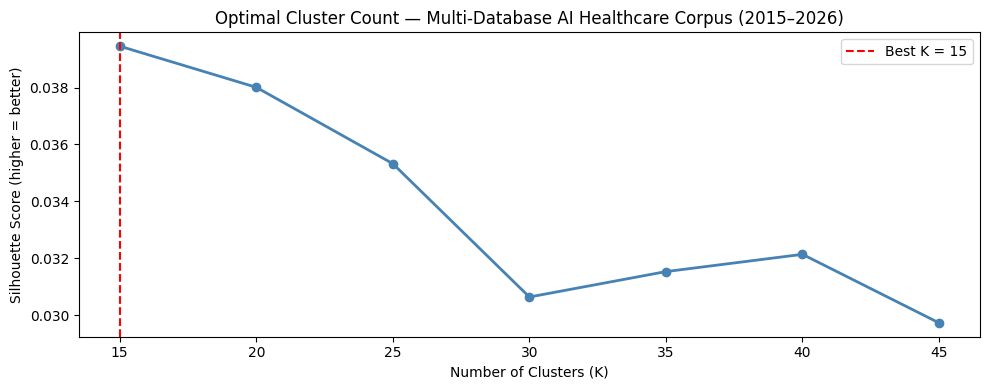

✅ Saved: optimal_k.png

✅ Final clustering: 15 clusters
cluster
0     190
1     448
2     401
3     348
4     282
5     401
6     319
7     419
8     372
9     361
10    241
11    552
12    322
13    334
14    304


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — K-MEANS WITH OPTIMAL K SELECTION (SILHOUETTE)        ║
# ╚══════════════════════════════════════════════════════════════════╝

print("Testing K values from 15 to 45 to find optimal cluster count...")
print("(~4 minutes)\n")

k_range    = range(15, 46, 5)
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(embeddings)
    score  = silhouette_score(embeddings, labels, sample_size=1500, random_state=42)
    sil_scores.append(score)
    print(f"  K={k:3d}  →  Silhouette Score: {score:.4f}")

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\n✅ Optimal K = {best_k}")

# Silhouette plot
plt.figure(figsize=(10, 4))
plt.plot(list(k_range), sil_scores, marker="o", color="steelblue", linewidth=2)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score (higher = better)")
plt.title("Optimal Cluster Count — Multi-Database AI Healthcare Corpus (2015–2026)")
plt.legend()
plt.tight_layout()
plt.savefig("optimal_k.png", dpi=150)
plt.show()
print("✅ Saved: optimal_k.png")

# Final clustering
N_CLUSTERS = best_k
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(embeddings)
print(f"\n✅ Final clustering: {N_CLUSTERS} clusters")
print(df["cluster"].value_counts().sort_index().to_string())

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — IMPROVED TF-IDF CLUSTER LABELLING                    ║
# ║  Custom stop-word list prevents generic AI/health labels        ║
# ╚══════════════════════════════════════════════════════════════════╝

vectorizer = TfidfVectorizer(
    max_features=80000,
    stop_words="english",
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=3,
    max_df=0.6,
)
tfidf_matrix = vectorizer.fit_transform(df["full_text"].fillna(""))
feature_names = vectorizer.get_feature_names_out()

custom_stop_set = set(CUSTOM_STOPS)
zero_cols = [i for i, f in enumerate(feature_names) if f in custom_stop_set]
tfidf_lil = sp.lil_matrix(tfidf_matrix)
for col in zero_cols:
    tfidf_lil[:, col] = 0
tfidf_matrix = tfidf_lil.tocsr()

cluster_names = {}
for cid in range(N_CLUSTERS):
    mask = df["cluster"] == cid
    if mask.sum() == 0:
        cluster_names[cid] = f"cluster_{cid}"
        continue
    ctfidf  = tfidf_matrix[mask.to_numpy()].mean(axis=0)
    top_idx = np.asarray(ctfidf).flatten().argsort()[-5:][::-1]
    cluster_names[cid] = " | ".join([feature_names[i] for i in top_idx])
    print(f"Cluster {cid:2d} ({mask.sum():4d} papers): {cluster_names[cid]}")

df["cluster_name"] = df["cluster"].map(cluster_names)
print("\n✅ Cluster labelling complete")

Cluster  0 ( 190 papers): rehabilitation | stroke | motor | limb | robotic
Cluster  1 ( 448 papers): segmentation | images | image | feature | classification
Cluster  2 ( 401 papers): precision | medicine | technologies | digital | research
Cluster  3 ( 348 papers): intelligence ai | artificial intelligence ai | diagnostic | detection | imaging
Cluster  4 ( 282 papers): genes | gene | expression | mechanisms | molecular
Cluster  5 ( 401 papers): language | large language | language models | large language models | llms
Cluster  6 ( 319 papers): wearable | monitoring | sensor | detection | sensors
Cluster  7 ( 419 papers): drug | protein | discovery | drug discovery | molecular
Cluster  8 ( 372 papers): risk | ml | predicting | learning ml | machine learning ml
Cluster  9 ( 361 papers): robot | robotic | robots | human | control
Cluster 10 ( 241 papers): radiomics | ct | cancer | carcinoma | survival
Cluster 11 ( 552 papers): intelligence ai | artificial intelligence ai | applications |

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — CLUSTER INTERPRETATION REPORT                        ║
# ║  Top keywords + 3 most representative papers per cluster        ║
# ╚══════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("CLUSTER INTERPRETATION REPORT")
print("=" * 70)

report_rows = []
for cid in range(N_CLUSTERS):
    mask       = df["cluster"] == cid
    cluster_df = df[mask].copy()
    n          = len(cluster_df)
    label      = cluster_names[cid]

    cluster_embs = embeddings[mask.to_numpy()]
    centroid     = cluster_embs.mean(axis=0, keepdims=True)
    sims         = cosine_similarity(centroid, cluster_embs)[0]
    top3_idx     = sims.argsort()[-3:][::-1]
    rep_titles   = cluster_df.iloc[top3_idx]["title"].tolist()

    print(f"\nCLUSTER {cid:2d} — {n} papers")
    print(f"  Keywords: {label}")
    for t in rep_titles:
        print(f"    • {str(t)[:95]}")

    report_rows.append({
        "cluster_id": cid, "n_papers": n, "keywords": label,
        "rep_paper_1": rep_titles[0] if len(rep_titles) > 0 else "",
        "rep_paper_2": rep_titles[1] if len(rep_titles) > 1 else "",
        "rep_paper_3": rep_titles[2] if len(rep_titles) > 2 else "",
    })

print("\n" + "="*70)
pd.DataFrame(report_rows).to_csv("cluster_report.csv", index=False)
print("✅ Saved: cluster_report.csv")

CLUSTER INTERPRETATION REPORT

CLUSTER  0 — 190 papers
  Keywords: rehabilitation | stroke | motor | limb | robotic
    • Personalized Adaptive Assistance With Reinforcement Learning Control Enhances Engagement, Perfo
    • Intelligent System for Upper Limb Motor Assessment Using Inertial Sensors and Machine Learning 
    • Haptic interaction with a human partner for ankle training in chronic stroke: a pilot study.

CLUSTER  1 — 448 papers
  Keywords: segmentation | images | image | feature | classification
    • DCSM-Unet: Dual-path heterogeneous encoder with content-aware guidance and differential feature
    • Multi-phase deep learning framework with Multiscale Adaptive Swin Transformer and embedding att
    • Multi-scale feature enhancement in multi-task learning for medical image analysis.

CLUSTER  2 — 401 papers
  Keywords: precision | medicine | technologies | digital | research
    • Genomics and Personalized Medicine: The DNA Revolution Reshaping Patient Care by 2035.
    • T

---
## PHASE 4 — VISUALISATION & ANALYSIS

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — UMAP 2D VISUALISATION                               ║
# ║  Interactive scatter plot — hover to read paper titles          ║
# ╚══════════════════════════════════════════════════════════════════╝

import umap
import plotly.express as px

print("Reducing to 2D with UMAP (~3 minutes)...")
reducer   = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords_2d = reducer.fit_transform(embeddings)

df["x"] = coords_2d[:, 0]
df["y"] = coords_2d[:, 1]

hover_cols = ["pmid","year","title","source_databases"]
hover_cols = [c for c in hover_cols if c in df.columns]

fig = px.scatter(
    df, x="x", y="y",
    color="cluster_name",
    hover_data=hover_cols,
    title=f"Biomedical AI Research Map — Multi-Database Corpus 2015–2026 (N={len(df):,})",
    width=1200, height=750
)
fig.show()
print("✅ UMAP visualisation rendered")

Reducing to 2D with UMAP (~3 minutes)...


✅ UMAP visualisation rendered


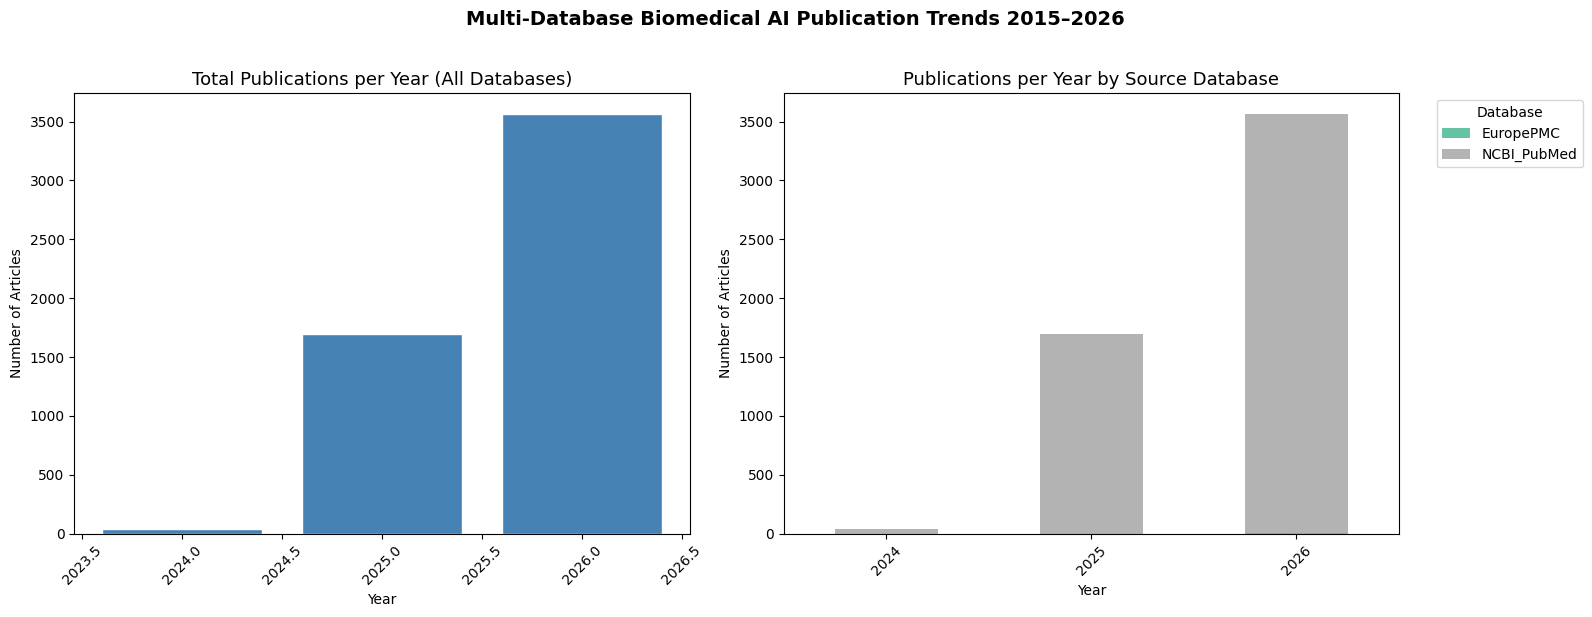

✅ Saved: publications_per_year.png

Year counts:
year
2024      37
2025    1695
2026    3562


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — PUBLICATION TREND BY YEAR & DATABASE                ║
# ╚══════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart A: Total articles per year
year_counts = df["year"].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Total Publications per Year (All Databases)", fontsize=13)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Articles")
axes[0].tick_params(axis="x", rotation=45)

# Chart B: Articles per year coloured by database
db_year = pd.crosstab(df["year"], df["source_db"])
db_year.plot(kind="bar", stacked=True, ax=axes[1],
             colormap="Set2", edgecolor="none")
axes[1].set_title("Publications per Year by Source Database", fontsize=13)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Articles")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Database", bbox_to_anchor=(1.05,1), loc="upper left")

plt.suptitle("Multi-Database Biomedical AI Publication Trends 2015–2026",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("publications_per_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: publications_per_year.png")
print("\nYear counts:")
print(year_counts.to_string())

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — DATABASE OVERLAP ANALYSIS                           ║
# ║  Shows which articles appear in multiple databases              ║
# ╚══════════════════════════════════════════════════════════════════╝

print("=== DATABASE COVERAGE REPORT ===\n")

# Total per DB
db_list = ["NCBI_PubMed","EuropePMC","Elsevier_Scopus"] # Removed "WebOfScience"
for db in db_list:
    n = df["source_databases"].str.contains(db).sum()
    pct = n / len(df) * 100
    print(f"  {db:<25} {n:>6,} articles  ({pct:.1f}% of corpus)")

# Overlap
if "multi_db" in df.columns:
    multi = df["multi_db"].sum()
    print(f"\n  Articles in 2+ databases: {multi:,} ({multi/len(df)*100:.1f}%)")

# Unique per DB
print("\n=== UNIQUE CONTRIBUTIONS (articles only in that DB) ===")
for db in db_list:
    in_db    = df["source_databases"].str.contains(db).fillna(False)
    only_db  = in_db & ~df["source_databases"].str.contains(";").fillna(False)
    print(f"  {db:<25} {only_db.sum():>6,} unique articles")

cluster_summary = df.groupby("cluster_name").agg(
    n_papers    = ("pmid","count"),
    year_min    = ("year","min"),
    year_max    = ("year","max"),
).sort_values("n_papers", ascending=False).reset_index()
cluster_summary["year_range"] = cluster_summary["year_min"].astype(str) + "–" + cluster_summary["year_max"].astype(str)
cluster_summary = cluster_summary.drop(columns=["year_min","year_max"])

print("\n=== CLUSTER SIZE RANKING ===\n")
print(cluster_summary.to_string(index=False))
cluster_summary.to_csv("cluster_summary.csv", index=False)
print("\n✅ Saved: cluster_summary.csv")

=== DATABASE COVERAGE REPORT ===

  NCBI_PubMed                5,290 articles  (99.9% of corpus)
  EuropePMC                      4 articles  (0.1% of corpus)
  Elsevier_Scopus                0 articles  (0.0% of corpus)

  Articles in 2+ databases: 0 (0.0%)

=== UNIQUE CONTRIBUTIONS (articles only in that DB) ===
  NCBI_PubMed                5,290 unique articles
  EuropePMC                      4 unique articles
  Elsevier_Scopus                0 unique articles

=== CLUSTER SIZE RANKING ===

                                                                       cluster_name  n_papers year_range
intelligence ai | artificial intelligence ai | applications | challenges | medicine       552  2024–2026
                           segmentation | images | image | feature | classification       448  2024–2026
                            drug | protein | discovery | drug discovery | molecular       419  2024–2026
         language | large language | language models | large language models | l

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — SEMANTIC SEARCH                                     ║
# ║  Finds papers closest to commercialisation concepts             ║
# ╚══════════════════════════════════════════════════════════════════╝

queries = [
    "AI startup commercialized into a healthcare product",
    "machine learning clinical decision support system deployed in hospital",
    "deep learning diagnostic tool economic impact cost reduction",
    "natural language processing hospital workflow automation",
    "AI model FDA approved regulatory clearance medical device",
    "technology transfer research commercialisation patent licensing",
    "precision medicine genomics clinical implementation startup",
]

print("=" * 72)
for q in queries:
    qemb   = model.encode([q])
    scores = cosine_similarity(qemb, embeddings)[0]
    df["score"] = scores
    top3 = df.nlargest(3, "score")[["year","pmid","title","source_databases","score"]]
    print(f"\nQUERY: '{q}'")
    for _, row in top3.iterrows():
        print(f"  [{row['year']}] {str(row['title'])[:88]}")
        db_tag = f"[{row.get('source_databases','?')}]" if "source_databases" in row else ""
        print(f"         PMID:{row['pmid']} | Score:{row['score']:.3f} | {db_tag}")
print("=" * 72)


QUERY: 'AI startup commercialized into a healthcare product'
  [2026] Strategic Key Performance Indicators for AI in Lead Optimization.
         PMID:41866813 | Score:0.512 | [NCBI_PubMed]
  [2026] Learning from the successes and failures of early artificial intelligence (AI) adoption 
         PMID:41614721 | Score:0.509 | [NCBI_PubMed]
  [2025] Generalizability of FDA-Approved AI-Enabled Medical Devices for Clinical Use.
         PMID:40305017 | Score:0.485 | [NCBI_PubMed]

QUERY: 'machine learning clinical decision support system deployed in hospital'
  [2026] Supervised Machine Learning and Clinical Decision Support.
         PMID:41206184 | Score:0.703 | [NCBI_PubMed]
  [2025] A Machine Learning-Based Clinical Decision Support System to Improve End-of-Life Care.
         PMID:41202856 | Score:0.687 | [NCBI_PubMed]
  [2026] Interpretable clinical decision support systems in high-risk pregnancy: a scoping review
         PMID:41495684 | Score:0.669 | [NCBI_PubMed]

QUERY: 'deep lea

---
## PHASE 5 — LENS.ORG SCHOLARLY ENRICHMENT
*(Skip Cells 14–15 if pubmed_corpus_enriched.csv exists on Drive)*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — TEST LENS.ORG CONNECTION                            ║
# ╚══════════════════════════════════════════════════════════════════╝

if not Lenswithpatent:
    print("❌ Lenswithpatent not found")
    print("   Add Lenswithpatent to Colab Secrets → 🔑 key icon")
else:
    url = "https://api.lens.org/scholarly/search"
    headers = {"Authorization": f"Bearer {Lenswithpatent}",
               "Content-Type": "application/json"}
    body = {
        "query": {"match": {"title": "artificial intelligence healthcare"}},
        "size": 1,
        "include": ["title","scholarly_citations_count"]
    }
    r = requests.post(url, json=body, headers=headers, timeout=15)
    if r.status_code == 200:
        res = r.json()["data"][0]
        print("✅ Lens.org connection successful")
        print(f"   Sample: {res.get('title','')[:80]}")
        print(f"   Citations: {res.get('scholarly_citations_count',0)}")
    else:
        print(f"❌ Failed: {r.status_code} — {r.text}")

NameError: name 'Lenswithpatent' is not defined

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — LENS.ORG ENRICHMENT (checkpoint-resumable)          ║
# ║  ⏱ 90–120 minutes for full corpus. Auto-resumes if interrupted. ║
# ╚══════════════════════════════════════════════════════════════════╝

ENRICHED_FILE    = "pubmed_corpus_enriched.csv"
CHECKPOINT_FILE  = "lens_checkpoint.csv"

if ENRICHED_FILE in os.listdir(PROJECT_DIR):
    print(f"✅ {ENRICHED_FILE} already on Drive — skipping")
    df = pd.read_csv(ENRICHED_FILE)
    print(f"   {len(df):,} articles | avg citations: {df['citation_count'].mean():.1f}")
elif not Lenswithpatent:
    print("❌ Lenswithpatent missing — skip this cell")
else:
    def get_lens_meta(pmid, doi, title, token):
        url = "https://api.lens.org/scholarly/search"
        headers = {"Authorization": f"Bearer {token}",
                   "Content-Type": "application/json"}
        fields = ["lens_id","scholarly_citations_count",
                  "open_access","year_published","source.publisher"]
        # Try DOI first (fastest)
        for query_body in [
            {"term": {"external_ids.value": str(doi)}} if doi else None,
            {"term": {"external_ids.value": str(pmid)}} if pmid else None,
            {"match": {"title": str(title)[:80]}} if title else None,
        ]:
            if query_body is None:
                continue
            try:
                r = requests.post(url,
                    json={"query": query_body, "size":1, "include": fields},
                    headers=headers, timeout=15)
                if r.status_code == 200 and r.json().get("total",0) > 0:
                    rec = r.json()["data"][0]
                    return {
                        "lens_id":        rec.get("lens_id",""),
                        "citation_count": rec.get("scholarly_citations_count",0),
                        "open_access":    rec.get("open_access",{}).get("is_oa",False),
                        "publisher":      rec.get("source",{}).get("publisher",""),
                        "lens_year":      rec.get("year_published",""),
                        "found": True
                    }
            except:
                pass
        return {"lens_id":"","citation_count":0,"open_access":False,
                "publisher":"","lens_year":"","found":False}

    # Resume from checkpoint
    if CHECKPOINT_FILE in os.listdir(PROJECT_DIR):
        done_df    = pd.read_csv(CHECKPOINT_FILE)
        done_pmids = set(done_df["_idx"].astype(str))
        print(f"▶ Resuming — {len(done_df)} done, {len(df)-len(done_df)} remaining")
        results = done_df.to_dict("records")
    else:
        done_pmids = set()
        results    = []

    not_found = 0
    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc="Lens enrichment")):
        if str(i) in done_pmids:
            continue
        meta = get_lens_meta(
            pmid  = row.get("pmid",""),
            doi   = row.get("doi",""),
            title = row.get("title",""),
            token = LENS_TOKEN
        )
        meta["_idx"] = i
        results.append(meta)
        if not meta["found"]:
            not_found += 1
        time.sleep(0.13)
        if (i+1) % 500 == 0:
            pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
            print(f"   💾 Checkpoint: {i+1} processed")

    meta_df = pd.DataFrame(results)
    df["lens_id"]        = meta_df["lens_id"].values[:len(df)]
    df["citation_count"] = meta_df["citation_count"].values[:len(df)]
    df["open_access"]    = meta_df["open_access"].values[:len(df)]
    df["publisher"]      = meta_df["publisher"].values[:len(df)]
    df["lens_year"]      = meta_df["lens_year"].values[:len(df)]
    df["lens_found"]     = meta_df["found"].values[:len(df)]
    df.to_csv(ENRICHED_FILE, index=False)

    if CHECKPOINT_FILE in os.listdir(PROJECT_DIR):
        os.remove(CHECKPOINT_FILE)

    matched = int(df["lens_found"].sum())
    print(f"\n{'='*55}")
    print(f"✅ ENRICHMENT COMPLETE")
    print(f"  Total articles       : {len(df):,}")
    print(f"  Matched in Lens      : {matched:,} ({matched/len(df)*100:.1f}%)")
    print(f"  Avg citation count   : {df['citation_count'].mean():.1f}")
    print(f"  Median citations     : {df['citation_count'].median():.0f}")
    print(f"  Open access rate     : {df['open_access'].mean()*100:.1f}%")
    print(f"  Saved to Drive       : {ENRICHED_FILE}")
    print(f"{'='*55}")

---
## PHASE 6 — CITATION IMPACT ANALYSIS

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — CITATION IMPACT BY RESEARCH CLUSTER                 ║
# ║  Produces Table 4 for the book chapter                         ║
# ╚══════════════════════════════════════════════════════════════════╝

if "citation_count" not in df.columns:
    print("⚠️  citation_count missing — run CELL 15 first")
elif "cluster_name" not in df.columns:
    print("⚠️  cluster_name missing — run CELL 0 first")
else:
    citation_by_cluster = df.groupby("cluster_name").agg(
        n_papers         = ("pmid",           "count"),
        total_citations  = ("citation_count",  "sum"),
        mean_citations   = ("citation_count",  "mean"),
        median_citations = ("citation_count",  "median"),
        max_citations    = ("citation_count",  "max"),
        open_access_pct  = ("open_access",
                            lambda x: round(x.astype(bool).mean()*100, 1))
    ).reset_index()
    citation_by_cluster["mean_citations"] = citation_by_cluster["mean_citations"].round(1)
    citation_by_cluster = citation_by_cluster.sort_values("mean_citations", ascending=False)

    print("=== CITATION IMPACT BY RESEARCH CLUSTER ===\n")
    print(citation_by_cluster.to_string(index=False))
    citation_by_cluster.to_csv("citation_by_cluster.csv", index=False)
    print("\n✅ Saved: citation_by_cluster.csv")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — PUBLICATION-READY CHARTS                            ║
# ╚══════════════════════════════════════════════════════════════════╝

citation_by_cluster = pd.read_csv("citation_by_cluster.csv")

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle(
    "Scholarly Impact — Biomedical AI Research 2015–2026\n"
    "Multi-Database Corpus · PubMedBERT Clusters · Lens.org Citation Data",
    fontsize=13, fontweight="bold", y=1.02
)

def shorten(s, n=38):
    parts = str(s).split("|")
    label = parts[0].strip()
    return (label[:n] + "…") if len(label) > n else label

# Chart A — Mean citations (top 15)
top15 = citation_by_cluster.head(15).copy()
top15["label"] = top15["cluster_name"].apply(shorten)
sns.barplot(data=top15, x="mean_citations", y="label",
            palette="Blues_d", ax=axes[0])
axes[0].set_title("Mean Citations per Paper\n(Top 15 Clusters)", fontsize=12)
axes[0].set_xlabel("Mean Citation Count")
axes[0].set_ylabel("")

# Chart B — Open access rate (top 15)
top15_oa = citation_by_cluster.sort_values("open_access_pct", ascending=False).head(15).copy()
top15_oa["label"] = top15_oa["cluster_name"].apply(shorten)
sns.barplot(data=top15_oa, x="open_access_pct", y="label",
            palette="Greens_d", ax=axes[1])
axes[1].set_title("Open Access Rate (%)\n(Top 15 Clusters)", fontsize=12)
axes[1].set_xlabel("Open Access (%)")
axes[1].set_ylabel("")

# Chart C — Citation distribution
axes[2].hist(df["citation_count"].clip(upper=300),
             bins=50, color="steelblue", edgecolor="white")
axes[2].set_title("Citation Count Distribution\n(Full Corpus, capped at 300)", fontsize=12)
axes[2].set_xlabel("Citation Count")
axes[2].set_ylabel("Number of Papers")
med = df["citation_count"].median()
axes[2].axvline(med, color="red", linestyle="--", label=f"Median = {med:.0f}")
axes[2].legend()

plt.tight_layout()
plt.savefig("scholarly_impact_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: scholarly_impact_charts.png")

---
## PHASE 7 — PATENT ANALYSIS
*(Run after Lens.org Patent API is approved)*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — PATENT CITATION ANALYSIS (Patent API required)      ║
# ╚══════════════════════════════════════════════════════════════════╝

PATENT_TOKEN = "PASTE_PATENT_TOKEN_HERE"

if PATENT_TOKEN == "PASTE_PATENT_TOKEN_HERE":
    print("⏳ Patent API token not yet configured")
    print("\n   When Lens.org grants Patent API access:")
    print("   1. Generate token on lens.org/lens/user/subscriptions")
    print("   2. Replace PASTE_PATENT_TOKEN_HERE above")
    print("   3. Run this cell → then CELL 19 → then CELL 20")
else:
    def check_patent_citation(pmid, doi, token):
        url = "https://api.lens.org/patent/search"
        headers = {"Authorization": f"Bearer {token}",
                   "Content-Type": "application/json"}
        # Try DOI reference first, then PMID
        for search_term in [doi, str(pmid)]:
            if not search_term:
                continue
            body = {
                "query": {"match": {"references.npl_text": search_term}},
                "size": 1, "include": ["lens_id"]
            }
            try:
                r = requests.post(url, json=body, headers=headers, timeout=10)
                if r.json().get("total", 0) > 0:
                    return True
            except:
                pass
        return False

    # Test on 5 papers
    print("Testing patent check on 5 papers...")
    for _, row in df.head(5).iterrows():
        result = check_patent_citation(
            row.get("pmid",""), row.get("doi",""), PATENT_TOKEN)
        print(f"  PMID {row.get('pmid','?')}: patent cited = {result}")
        time.sleep(1)

    # Run on 500-paper sample
    print("\nRunning on 500-paper sample (~10 minutes)...")
    sample_df     = df.sample(500, random_state=42).copy()
    patent_cited  = []
    for _, row in tqdm(sample_df.iterrows(), total=500):
        cited = check_patent_citation(
            row.get("pmid",""), row.get("doi",""), PATENT_TOKEN)
        patent_cited.append(cited)
        time.sleep(1.1)

    sample_df["patent_cited"] = patent_cited
    sample_df.to_csv("sample_with_patents.csv", index=False)
    print(f"\n✅ Patent citations found: {sum(patent_cited)} / 500")
    print(f"   Commercialisation rate: {sum(patent_cited)/500*100:.1f}%")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 19 — COMMERCIALISATION RATE BY CLUSTER                   ║
# ╚══════════════════════════════════════════════════════════════════╝

if "sample_with_patents.csv" not in os.listdir(PROJECT_DIR):
    print("⏳ Run CELL 18 first")
else:
    sample_df = pd.read_csv("sample_with_patents.csv")
    conversion = sample_df.groupby("cluster_name").agg(
        n_papers         = ("pmid","count"),
        n_commercialized = ("patent_cited","sum")
    ).reset_index()
    conversion["conversion_rate_%"] = (
        conversion["n_commercialized"] / conversion["n_papers"] * 100
    ).round(1)
    conversion = conversion.sort_values("conversion_rate_%", ascending=False)
    print(conversion.to_string(index=False))
    conversion.to_csv("conversion_by_cluster.csv", index=False)

    plt.figure(figsize=(14, 8))
    top15c = conversion.head(15).copy()
    top15c["label"] = top15c["cluster_name"].apply(
        lambda x: str(x).split("|")[0].strip()[:40] + "…")
    sns.barplot(data=top15c, x="conversion_rate_%", y="label", palette="viridis")
    plt.xlabel("Patent Citation Rate (%)", fontsize=13)
    plt.ylabel("Research Cluster", fontsize=13)
    plt.title("Research-to-Commercialisation Rate by Domain\n"
              "PubMedBERT Clusters · Lens.org Patent API · 2015–2026", fontsize=14)
    plt.tight_layout()
    plt.savefig("conversion_chart.png", dpi=150)
    plt.show()
    print("✅ Saved: conversion_chart.png")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 20 — VERIFY ALL FILES ON GOOGLE DRIVE                    ║
# ╚══════════════════════════════════════════════════════════════════╝

expected = {
    "pubmed_corpus_ncbi.csv":          "NCBI/PubMed corpus",
    "pubmed_corpus_europepmc.csv":     "EuropePMC corpus",
    "pubmed_corpus_elsevier.csv":      "Elsevier/Scopus corpus",
    "pubmed_corpus_wos.csv":           "Web of Science corpus",
    "pubmed_corpus_merged.csv":        "Merged & deduplicated corpus",
    "pubmed_corpus_enriched.csv":      "Corpus + Lens.org citation data",
    "pubmed_embeddings.npy":           "PubMedBERT embedding matrix",
    "cluster_report.csv":              "Cluster labels + representative papers",
    "cluster_summary.csv":             "Cluster sizes and year ranges",
    "citation_by_cluster.csv":         "Citation impact by domain",
    "optimal_k.png":                   "Silhouette score chart",
    "publications_per_year.png":       "Annual trend + database breakdown",
    "scholarly_impact_charts.png":     "3-panel citation analysis",
    "sample_with_patents.csv":         "Patent citation results (500-paper sample)",
    "conversion_by_cluster.csv":       "Commercialisation rates",
    "conversion_chart.png":            "Patent conversion bar chart",
}

files_on_drive = os.listdir(PROJECT_DIR)
print(f"Drive path: {PROJECT_DIR}\n")
all_good = True
for fname, desc in expected.items():
    if fname in files_on_drive:
        kb = os.path.getsize(fname) / 1024
        print(f"  ✅ {fname:<45} {kb:>8.0f} KB   {desc}")
    else:
        status = "⏳ (patent cells)" if "patent" in fname or "conversion" in fname else "❌ missing"
        print(f"  {status} {fname:<45}  {desc}")
        if "patent" not in fname and "conversion" not in fname:
            all_good = False

print()
if all_good:
    print("✅ All core files present on Drive.")
else:
    print("⚠️  Some files missing — check which cells need to be re-run.")